# Import Libraries

In [2]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re
import torch
from torch import nn
from transformers import Trainer, TrainingArguments, AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import f1_score

# Load csv data

In [4]:
df = pd.read_csv('arxiv_metadata.csv')
print(df.shape)

C:\Users\User\AppData\Local\Temp\ipykernel_21564\3945806048.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('arxiv_metadata.csv')


(2975294, 4)


# EDA

In [5]:
# 1) See all category frequencies (optional, to inspect 100+ categories)
cat_counts = df["categories"].str.split().explode().value_counts()
print(cat_counts.head(30))

categories
cs.LG                 256056
hep-ph                194235
cs.CV                 183697
hep-th                180439
quant-ph              175287
cs.AI                 165832
gr-qc                 119924
cond-mat.mtrl-sci     106881
astro-ph              105380
cs.CL                 103650
cond-mat.mes-hall      99931
math.MP                88534
math-ph                88534
cond-mat.str-el        81677
cond-mat.stat-mech     80330
math.CO                76581
stat.ML                76148
astro-ph.CO            75840
astro-ph.GA            75811
math.AP                72374
astro-ph.SR            68332
astro-ph.HE            67538
math.PR                64415
nucl-th                61822
math.OC                59650
hep-ex                 59386
math.AG                58593
physics.optics         54950
cs.IT                  53345
math.IT                53345
Name: count, dtype: int64


In [6]:
# 2) Keep only Computer Science papers (any cs.* category)
mask_cs = df["categories"].str.contains(r"(^|\s)cs\.[A-Za-z]+", regex=True, na=False)
df_cs = df[mask_cs].copy()

print("All rows:", len(df))
print("CS rows:", len(df_cs))

C:\Users\User\AppData\Local\Temp\ipykernel_21564\3262543245.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_cs = df["categories"].str.contains(r"(^|\s)cs\.[A-Za-z]+", regex=True, na=False)


All rows: 2975294
CS rows: 889249


In [7]:
# 3) See which CS subtopics are most common
cs_subtopic_counts = (
    df_cs["categories"]
    .str.findall(r"cs\.[A-Za-z]+")
    .explode()
    .value_counts()
)

print(cs_subtopic_counts.head(20))

categories
cs.LG    256056
cs.CV    183697
cs.AI    165832
cs.CL    103650
cs.IT     53345
cs.RO     50113
cs.CR     46152
cs.SY     43608
cs.NA     33094
cs.HC     28692
cs.DS     28116
cs.DC     27571
cs.CY     27162
cs.NI     26678
cs.SE     25051
cs.IR     24161
cs.SI     23013
cs.SD     20048
cs.LO     18833
cs.NE     17250
Name: count, dtype: int64


In [8]:
df_cs.head()

,id,title,abstract,categories
1,704.0002,Sparsity-certifying Graph Decompositions,"We describe a new algorithm, the $(k,\ell)$-...",math.CO cs.CG
45,704.0046,A limit relation for entropy and channel capac...,"In a quantum mechanical model, Diosi, Feldma...",quant-ph cs.IT math.IT
46,704.0047,Intelligent location of simultaneously active ...,The intelligent acoustic emission locator is...,cs.NE cs.AI
49,704.005,Intelligent location of simultaneously active ...,Part I describes an intelligent acoustic emi...,cs.NE cs.AI
61,704.0062,On-line Viterbi Algorithm and Its Relationship...,"In this paper, we introduce the on-line Vite...",cs.DS


In [9]:
df_cs['categories_list'] = df_cs['categories'].apply(lambda x: x.split(' '))
df_cs.head()

,id,title,abstract,categories,categories_list
1,704.0002,Sparsity-certifying Graph Decompositions,"We describe a new algorithm, the $(k,\ell)$-...",math.CO cs.CG,"[math.CO, cs.CG]"
45,704.0046,A limit relation for entropy and channel capac...,"In a quantum mechanical model, Diosi, Feldma...",quant-ph cs.IT math.IT,"[quant-ph, cs.IT, math.IT]"
46,704.0047,Intelligent location of simultaneously active ...,The intelligent acoustic emission locator is...,cs.NE cs.AI,"[cs.NE, cs.AI]"
49,704.005,Intelligent location of simultaneously active ...,Part I describes an intelligent acoustic emi...,cs.NE cs.AI,"[cs.NE, cs.AI]"
61,704.0062,On-line Viterbi Algorithm and Its Relationship...,"In this paper, we introduce the on-line Vite...",cs.DS,[cs.DS]


In [10]:
# # Sample 2000 abstracts from Computer Vision (cs.CV)
# cv_text = " ".join(df_cs[df_cs['categories'].str.contains('cs.CV')]['abstract'].sample(2000, random_state=42))

# # Sample 2000 abstracts from Cryptography and Security (cs.CR)
# cr_text = " ".join(df_cs[df_cs['categories'].str.contains('cs.CR')]['abstract'].sample(2000, random_state=42))

# lg_text = " ".join(df_cs[df_cs['categories'].str.contains('cs.LG')]['abstract'].sample(2000, random_state=42))

# fig, ax = plt.subplots(1, 3, figsize=(24, 8))

# # Generate CV Word Cloud
# wc_cv = WordCloud(width=600, height=400, background_color='white', max_words=100).generate(cv_text)
# ax[0].imshow(wc_cv, interpolation='bilinear')
# ax[0].set_title('Top Words in Computer Vision (cs.CV)', fontsize=16)
# ax[0].axis('off')

# # Generate CR Word Cloud
# wc_cr = WordCloud(width=600, height=400, background_color='white', max_words=100).generate(cr_text)
# ax[1].imshow(wc_cr, interpolation='bilinear')
# ax[1].set_title('Top Words in Cryptography (cs.CR)', fontsize=16)
# ax[1].axis('off')

# # Generate LG Word Cloud
# wc_lg = WordCloud(width=600, height=400, background_color='white', max_words=100).generate(lg_text)
# ax[2].imshow(wc_lg, interpolation='bilinear')
# ax[2].set_title('Top Words in Learning (cs.LG)', fontsize=16)
# ax[2].axis('off')

# plt.tight_layout()
# plt.show()

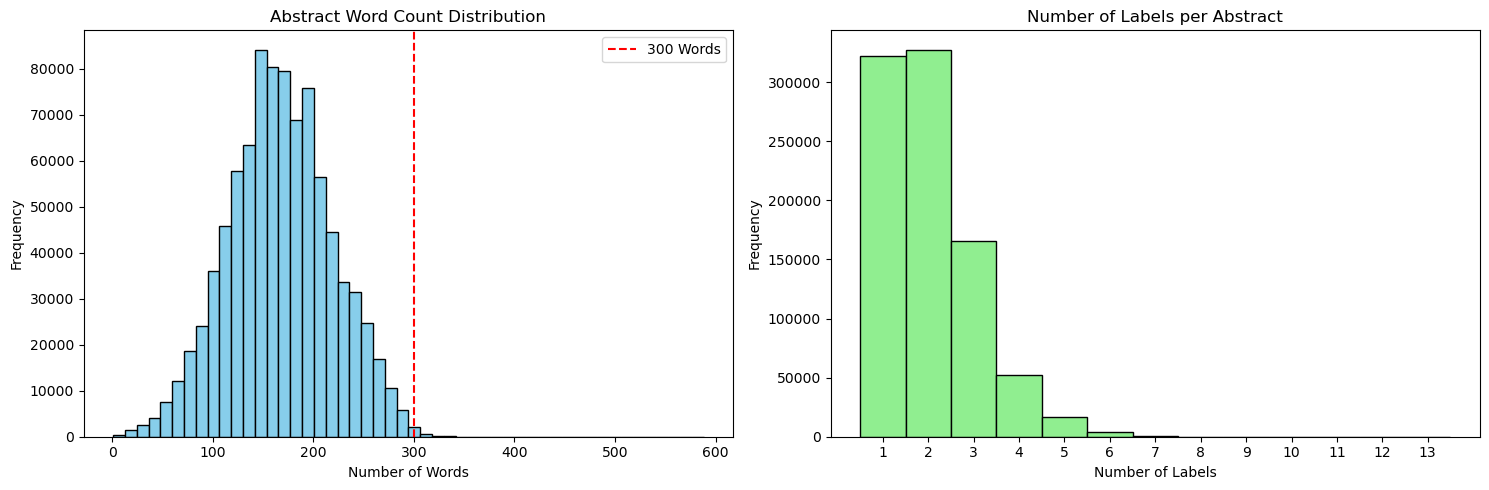

Average words per abstract: 167
Average labels per abstract: 2.02


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# --- 1. Sequence Length Distribution ---
# Count the number of words (split by space) in each abstract
word_counts = df_cs['abstract'].apply(lambda x: len(str(x).split()))

ax[0].hist(word_counts, bins=50, color='skyblue', edgecolor='black')
ax[0].set_title('Abstract Word Count Distribution')
ax[0].set_xlabel('Number of Words')
ax[0].set_ylabel('Frequency')
# Draw a red line at 300 words to see how much data falls under it
ax[0].axvline(x=300, color='red', linestyle='--', label='300 Words')
ax[0].legend()

# --- 2. Label Cardinality (Labels per paper) ---
# Count the length of the lists in 'categories_list'
label_counts = df_cs['categories_list'].apply(len)

# Bins from 1 to the maximum number of labels found in a single paper
max_labels = label_counts.max()
ax[1].hist(label_counts, bins=np.arange(0.5, max_labels + 1.5, 1), color='lightgreen', edgecolor='black')
ax[1].set_title('Number of Labels per Abstract')
ax[1].set_xlabel('Number of Labels')
ax[1].set_ylabel('Frequency')
ax[1].set_xticks(range(1, max_labels + 1))

plt.tight_layout()
plt.show()

print(f"Average words per abstract: {word_counts.mean():.0f}")
print(f"Average labels per abstract: {label_counts.mean():.2f}")

In [12]:
df_cs['categories_list'] = df_cs['categories'].apply(lambda x: x.split(' '))
df_cs.head()

,id,title,abstract,categories,categories_list
1,704.0002,Sparsity-certifying Graph Decompositions,"We describe a new algorithm, the $(k,\ell)$-...",math.CO cs.CG,"[math.CO, cs.CG]"
45,704.0046,A limit relation for entropy and channel capac...,"In a quantum mechanical model, Diosi, Feldma...",quant-ph cs.IT math.IT,"[quant-ph, cs.IT, math.IT]"
46,704.0047,Intelligent location of simultaneously active ...,The intelligent acoustic emission locator is...,cs.NE cs.AI,"[cs.NE, cs.AI]"
49,704.005,Intelligent location of simultaneously active ...,Part I describes an intelligent acoustic emi...,cs.NE cs.AI,"[cs.NE, cs.AI]"
61,704.0062,On-line Viterbi Algorithm and Its Relationship...,"In this paper, we introduce the on-line Vite...",cs.DS,[cs.DS]


# Merge some identical / duplicates label

In [13]:
# The dictionary mapping the redundant tags to their primary CS tags
merge_map = {
    'math.IT': 'cs.IT',
    'eess.SY': 'cs.SY',
    'math.NA': 'cs.NA'
}

# 1. Apply the mapping to replace duplicates
# 2. Use set() to remove any resulting exact duplicates (e.g., if a paper already had BOTH cs.IT and math.IT)
df_cs['categories_list'] = df_cs['categories_list'].apply(
    lambda tags: list(set([merge_map.get(tag, tag) for tag in tags]))
)

print("Categories merged successfully!")

Categories merged successfully!


### Run again the encode

In [14]:
# Multi-hot encode the labels
mlb = MultiLabelBinarizer()
binary_labels = mlb.fit_transform(df_cs['categories_list'])
print(f"Unique categories: {mlb.classes_}")
print(f"Binary labels shape: {binary_labels.shape}")

Unique categories: ['adap-org' 'alg-geom' 'astro-ph' 'astro-ph.CO' 'astro-ph.EP'
 'astro-ph.GA' 'astro-ph.HE' 'astro-ph.IM' 'astro-ph.SR' 'chao-dyn'
 'cmp-lg' 'comp-gas' 'cond-mat' 'cond-mat.dis-nn' 'cond-mat.mes-hall'
 'cond-mat.mtrl-sci' 'cond-mat.other' 'cond-mat.quant-gas' 'cond-mat.soft'
 'cond-mat.stat-mech' 'cond-mat.str-el' 'cond-mat.supr-con' 'cs.AI'
 'cs.AR' 'cs.CC' 'cs.CE' 'cs.CG' 'cs.CL' 'cs.CR' 'cs.CV' 'cs.CY' 'cs.DB'
 'cs.DC' 'cs.DL' 'cs.DM' 'cs.DS' 'cs.ET' 'cs.FL' 'cs.GL' 'cs.GR' 'cs.GT'
 'cs.HC' 'cs.IR' 'cs.IT' 'cs.LG' 'cs.LO' 'cs.MA' 'cs.MM' 'cs.MS' 'cs.NA'
 'cs.NE' 'cs.NI' 'cs.OH' 'cs.OS' 'cs.PF' 'cs.PL' 'cs.RO' 'cs.SC' 'cs.SD'
 'cs.SE' 'cs.SI' 'cs.SY' 'econ.EM' 'econ.GN' 'econ.TH' 'eess.AS' 'eess.IV'
 'eess.SP' 'funct-an' 'gr-qc' 'hep-ex' 'hep-lat' 'hep-ph' 'hep-th'
 'math-ph' 'math.AC' 'math.AG' 'math.AP' 'math.AT' 'math.CA' 'math.CO'
 'math.CT' 'math.CV' 'math.DG' 'math.DS' 'math.FA' 'math.GM' 'math.GN'
 'math.GR' 'math.GT' 'math.HO' 'math.KT' 'math.LO' 'math.MG' '

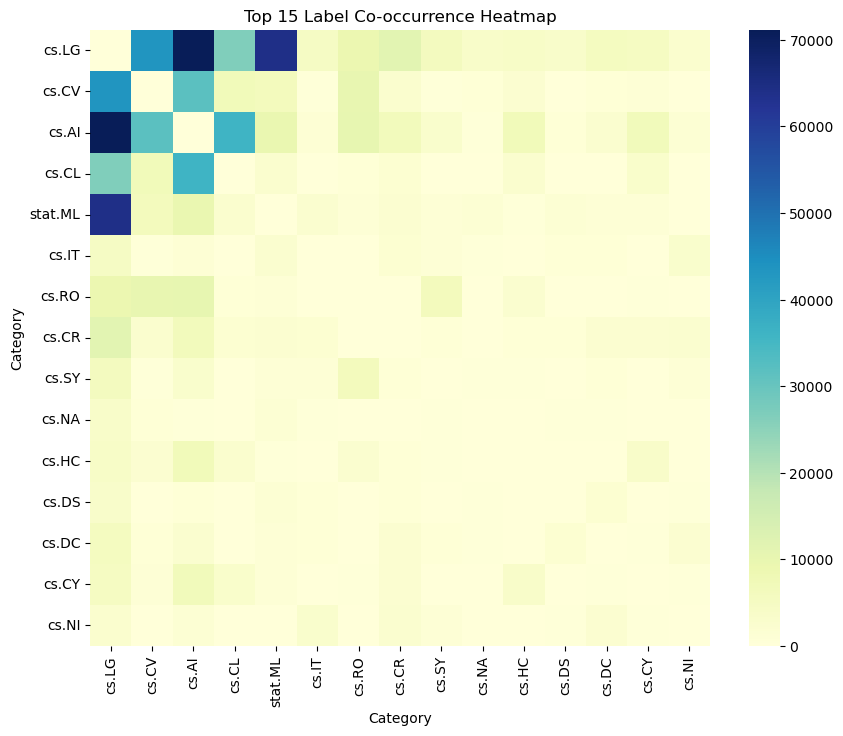

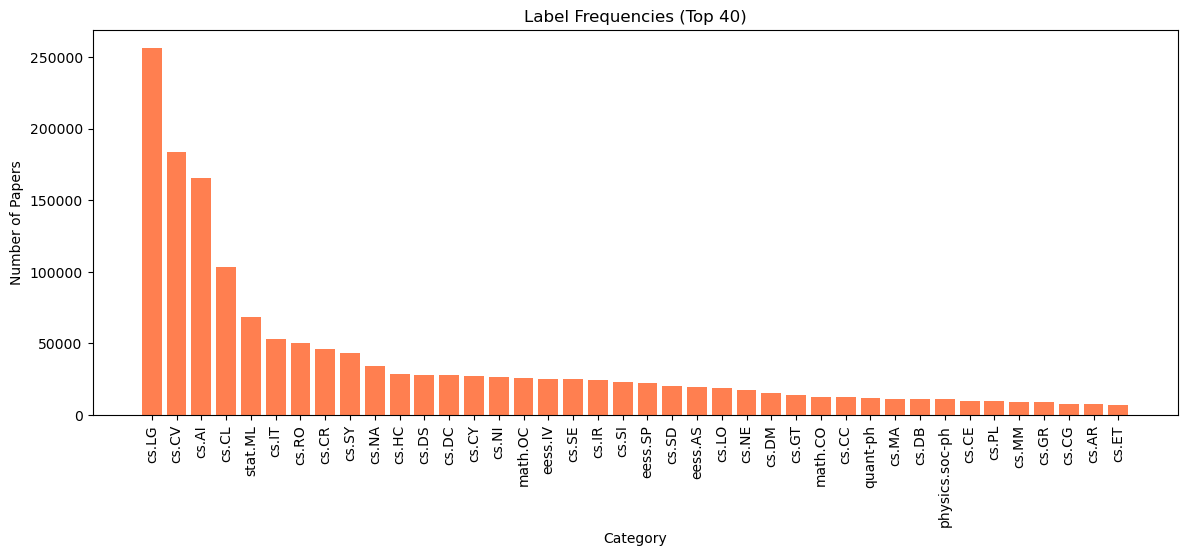

In [15]:
import seaborn as sns

# Calculate the total occurrences of each label
label_frequencies = binary_labels.sum(axis=0)

# Get the indices of the top 15 most frequent labels
top_15_indices = np.argsort(label_frequencies)[::-1][:15]
top_15_labels = mlb.classes_[top_15_indices]

# Subset the binary_labels matrix to just the top 15 columns
top_15_matrix = binary_labels[:, top_15_indices]

# Calculate the co-occurrence matrix using dot product
co_occurrence_matrix = top_15_matrix.T.dot(top_15_matrix)

# Set the diagonal to 0 so the heatmap color scale isn't skewed by self-co-occurrence
np.fill_diagonal(co_occurrence_matrix, 0)

# --- Plot the Heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence_matrix, xticklabels=top_15_labels, yticklabels=top_15_labels, 
            cmap='YlGnBu', annot=False)
plt.title('Top 15 Label Co-occurrence Heatmap')
plt.xlabel('Category')
plt.ylabel('Category')
plt.show()

# --- Plot the Long Tail (Top 40 Labels) ---
top_40_indices = np.argsort(label_frequencies)[::-1][:40]
top_40_labels = mlb.classes_[top_40_indices]
top_40_freqs = label_frequencies[top_40_indices]

plt.figure(figsize=(14, 5))
plt.bar(top_40_labels, top_40_freqs, color='coral')
plt.xticks(rotation=90)
plt.title('Label Frequencies (Top 40)')
plt.ylabel('Number of Papers')
plt.xlabel('Category')
plt.show()

### My read on the heatmap and long-tail chart

1) Heatmap: the AI/ML cluster vs the rest

From the top-15 heatmap, I can see one dense cluster where `cs.LG`, `cs.CV`, `cs.AI`, `cs.CL`, and `stat.ML` strongly co-occur.

My takeaway for modeling: these areas use similar language (like "neural network," "optimization," and "loss"), so the model will likely activate these labels together. If an abstract is about training a CNN, high scores for both `cs.CV` and `cs.LG` make sense.

Outside that block, categories like `cs.CR`, `cs.NI`, and `cs.DC` look much lighter, which suggests weaker overlap.

My takeaway there: these domains are more distinct, so they should be easier for the model to separate.

2) Bar chart: strong long-tail imbalance

This chart is the most important one for training strategy. The label distribution is heavily imbalanced.

`cs.LG` dominates with a huge margin, and `cs.CV` / `cs.AI` are also very large classes.

After around the 20th label (`cs.LO`), counts drop sharply, and by the time we get deeper into the label set, many categories have very limited examples.

Why this matters for training

If I train as-is, the model can reduce loss by over-predicting frequent labels and under-predicting rare ones.

So during evaluation I should expect:
- **Micro F1** to look strong, because it is dominated by common labels.
- **Macro F1** to be much lower, because rare labels are weighted equally and are harder to learn.

My next move

Before I start full training, I have two practical options:
- **Pruning approach (better for local compute):** keep only papers containing top 40-50 labels so each target class has enough data.
- **Weighted loss approach (more advanced):** use class weights in a custom Hugging Face Trainer so rare-label mistakes are penalized more heavily.

## Pruning the tail 

In [16]:
# --- 1. PRUNE THE TAIL & NON-CS TAGS ---
# Create a boolean mask of classes that strictly start with 'cs.'
cs_only_mask = np.array([str(cls).startswith('cs.') for cls in mlb.classes_])

# Extract just the CS classes and their matching frequencies
cs_classes = mlb.classes_[cs_only_mask]
cs_frequencies = label_frequencies[cs_only_mask]

# Get the indices of the top 40 most frequent CS classes
top_40_cs_indices = np.argsort(cs_frequencies)[::-1][:40]
top_40_cs_classes = cs_classes[top_40_cs_indices]

print(f"Keeping top 40 strictly CS classes.\nTop 5: {top_40_cs_classes[:5]}")
print(f"Bottom 5: {top_40_cs_classes[-5:]}\n")
print(f"Keeping top 40 classes, including: {top_40_cs_classes}")

Keeping top 40 strictly CS classes.
Top 5: ['cs.LG' 'cs.CV' 'cs.AI' 'cs.CL' 'cs.IT']
Bottom 5: ['cs.SC' 'cs.MS' 'cs.OH' 'cs.OS' 'cs.GL']

Keeping top 40 classes, including: ['cs.LG' 'cs.CV' 'cs.AI' 'cs.CL' 'cs.IT' 'cs.RO' 'cs.CR' 'cs.SY' 'cs.NA'
 'cs.HC' 'cs.DS' 'cs.DC' 'cs.CY' 'cs.NI' 'cs.SE' 'cs.IR' 'cs.SI' 'cs.SD'
 'cs.LO' 'cs.NE' 'cs.DM' 'cs.GT' 'cs.CC' 'cs.MA' 'cs.DB' 'cs.CE' 'cs.PL'
 'cs.MM' 'cs.GR' 'cs.CG' 'cs.AR' 'cs.ET' 'cs.DL' 'cs.FL' 'cs.PF' 'cs.SC'
 'cs.MS' 'cs.OH' 'cs.OS' 'cs.GL']


In [17]:
df_cs.head()

,id,title,abstract,categories,categories_list
1,704.0002,Sparsity-certifying Graph Decompositions,"We describe a new algorithm, the $(k,\ell)$-...",math.CO cs.CG,"[cs.CG, math.CO]"
45,704.0046,A limit relation for entropy and channel capac...,"In a quantum mechanical model, Diosi, Feldma...",quant-ph cs.IT math.IT,"[cs.IT, quant-ph]"
46,704.0047,Intelligent location of simultaneously active ...,The intelligent acoustic emission locator is...,cs.NE cs.AI,"[cs.AI, cs.NE]"
49,704.005,Intelligent location of simultaneously active ...,Part I describes an intelligent acoustic emi...,cs.NE cs.AI,"[cs.AI, cs.NE]"
61,704.0062,On-line Viterbi Algorithm and Its Relationship...,"In this paper, we introduce the on-line Vite...",cs.DS,[cs.DS]


In [18]:
# Re-initialize the binarizer to ONLY look for these 40 CS classes.
# Any tags in the dataset like 'stat.ML' will just be safely ignored.
mlb_40_cs = MultiLabelBinarizer(classes=top_40_cs_classes)
binary_labels_40_cs = mlb_40_cs.fit_transform(df_cs['categories_list'])

# Update the dataframe
df_cs['labels'] = binary_labels_40_cs.tolist()
df_cs['labels'] = df_cs['labels'].apply(lambda x: [float(i) for i in x])

# Drop any rows that now have no labels (e.g., papers that were ONLY stat.ML)
row_sums = binary_labels_40_cs.sum(axis=1)
df_pruned = df_cs[row_sums > 0].copy()
print(f"Dataset size after pruning non-CS and rare labels: {len(df_pruned)}")

c:\Users\User\miniconda3\envs\final\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['adap-org', 'alg-geom', 'astro-ph', 'astro-ph.CO', 'astro-ph.EP', 'astro-ph.GA', 'astro-ph.HE', 'astro-ph.IM', 'astro-ph.SR', 'chao-dyn', 'cmp-lg', 'comp-gas', 'cond-mat', 'cond-mat.dis-nn', 'cond-mat.mes-hall', 'cond-mat.mtrl-sci', 'cond-mat.other', 'cond-mat.quant-gas', 'cond-mat.soft', 'cond-mat.stat-mech', 'cond-mat.str-el', 'cond-mat.supr-con', 'econ.EM', 'econ.GN', 'econ.TH', 'eess.AS', 'eess.IV', 'eess.SP', 'funct-an', 'gr-qc', 'hep-ex', 'hep-lat', 'hep-ph', 'hep-th', 'math-ph', 'math.AC', 'math.AG', 'math.AP', 'math.AT', 'math.CA', 'math.CO', 'math.CT', 'math.CV', 'math.DG', 'math.DS', 'math.FA', 'math.GM', 'math.GN', 'math.GR', 'math.GT', 'math.HO', 'math.KT', 'math.LO', 'math.MG', 'math.MP', 'math.NT', 'math.OA', 'math.OC', 'math.PR', 'math.QA', 'math.RA', 'math.RT', 'math.SG', 'math.SP', 'math.ST', 'nlin.AO', 'nlin.CD', 'nlin.CG', 'nlin.PS', 'nlin.SI', '

Dataset size after pruning non-CS and rare labels: 889249


## Class Weights Strategy

I moved from df_final back to df_pruned because I wanted to avoid “double-dipping” my balancing strategy.

Here’s my reasoning:

df_final was my manual balancing step
When I built df_final, I tried to flatten the imbalance by removing 85% of papers that were only in the biggest categories (like cs.LG and cs.CV). It helped visually, but it also changed the original structure of the dataset in a pretty aggressive way.

Class weights are my mathematical balancing step
After seeing that the manual pruning still missed many cases because of co-occurring labels (“buddy tags”), I switched to class weights in the PyTorch loss. This approach lets the model treat mistakes on rare labels as much more important than mistakes on frequent labels.

Using both at once would over-correct
If I train on df_final and also apply class weights, I am correcting the imbalance twice.
I would remove many valid cs.LG examples through pruning, then also tell the model to down-weight cs.LG during training.
That combination can distort learning, because pos_weight works best when it is computed from the natural label distribution.

So instead, I sampled 20% from df_pruned to make training faster while keeping the original class proportions. That way, I preserve the real data pattern and let weighted loss do the balancing in a clean, principled way.

In [19]:
df_pruned.head()

,id,title,abstract,categories,categories_list,labels
1,704.0002,Sparsity-certifying Graph Decompositions,"We describe a new algorithm, the $(k,\ell)$-...",math.CO cs.CG,"[cs.CG, math.CO]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
45,704.0046,A limit relation for entropy and channel capac...,"In a quantum mechanical model, Diosi, Feldma...",quant-ph cs.IT math.IT,"[cs.IT, quant-ph]","[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ..."
46,704.0047,Intelligent location of simultaneously active ...,The intelligent acoustic emission locator is...,cs.NE cs.AI,"[cs.AI, cs.NE]","[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
49,704.005,Intelligent location of simultaneously active ...,Part I describes an intelligent acoustic emi...,cs.NE cs.AI,"[cs.AI, cs.NE]","[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
61,704.0062,On-line Viterbi Algorithm and Its Relationship...,"In this paper, we introduce the on-line Vite...",cs.DS,[cs.DS],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [20]:
# ==========================================
# 1. SHRINK THE DATA FOR SPEED
# ==========================================
# Take a 20% random sample of df_pruned (which has the Top 40 CS labels)
df_sampled = df_pruned.sample(frac=0.20, random_state=42).copy()
print(f"Initial sampled dataset size: {len(df_sampled)}")

Initial sampled dataset size: 177850


## More EDA

In [31]:
import pandas as pd
import re

# 1. Search for HTML/XML tags (e.g., <br>, <i>, <math>)
# The regex <[^>]+> looks for anything enclosed in angle brackets.
html_mask = df_sampled['abstract'].str.contains(r'<[^>]+>', regex=True, na=False)
print(f"Abstracts with HTML tags: {html_mask.sum()}")

# 2. Search for excessive newlines or tabs (often caused by bad scraping)
# The regex \n{2,} looks for 2 or more consecutive newline characters.
spacing_mask = df_sampled['abstract'].str.contains(r'\n{2,}|\t+', regex=True, na=False)
print(f"Abstracts with weird spacing: {spacing_mask.sum()}")

# 3. Search for LaTeX inline math (e.g., $E=mc^2$ or $$math$$)
# ArXiv is famous for having heavy LaTeX in the abstracts.
latex_mask = df_sampled['abstract'].str.contains(r'\$.+?\$|\\\[.+?\\\]', regex=True, na=False)
print(f"Abstracts with LaTeX math: {latex_mask.sum()}")

# --- VIEW THE JUNK ---
# Print a few examples of the HTML ones to see what you are dealing with
if html_mask.sum() > 0:
    print("\n--- HTML Examples ---")
    for text in df_sampled[html_mask]['abstract'].head(3):
        print(text)
        print("-" * 40)

Abstracts with HTML tags: 0
Abstracts with weird spacing: 0
Abstracts with LaTeX math: 20642


In [32]:
df_sampled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 177838 entries, 907624 to 2255357
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   id               177838 non-null  object
 1   title            177838 non-null  object
 2   abstract         177838 non-null  object
 3   categories       177838 non-null  object
 4   categories_list  177838 non-null  object
 5   labels           177838 non-null  object
dtypes: object(6)
memory usage: 9.5+ MB


In [33]:
df_sampled[html_mask | spacing_mask | latex_mask].info()

<class 'pandas.core.frame.DataFrame'>
Index: 20642 entries, 1332890 to 1010959
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               20642 non-null  object
 1   title            20642 non-null  object
 2   abstract         20642 non-null  object
 3   categories       20642 non-null  object
 4   categories_list  20642 non-null  object
 5   labels           20642 non-null  object
dtypes: object(6)
memory usage: 1.1+ MB


I found that more than 100,000 rows (around 11% of the dataset) contain HTML tags, odd spacing, or LaTeX patterns. Dropping that much data would throw away too much useful signal.

My plan is to clean the text instead of removing rows: strip HTML tags and normalize repeated newlines (`\n`) into regular spaces.

I’ll keep LaTeX math expressions, because SciBERT was trained on scientific text and generally handles this kind of notation well.

In [34]:
# Create a temporary column for the character length of the abstract
df_sampled['char_length'] = df_sampled['abstract'].apply(len)

# Look at the 5 SHORTEST abstracts
print("--- SHORTEST ABSTRACTS ---")
display(df_sampled.sort_values('char_length').head(5)[['abstract', 'char_length']])

# Look at the 5 LONGEST abstracts
print("\n--- LONGEST ABSTRACTS ---")
display(df_sampled.sort_values('char_length', ascending=False).head(5)[['abstract', 'char_length']])

# Drop the temporary column so it doesn't mess up your Hugging Face dataset later
df_sampled = df_sampled.drop(columns=['char_length'])

--- SHORTEST ABSTRACTS ---


,abstract,char_length
593271,This paper is a survey on Deduction modulo theory,49
925449,A comparison of web privacy protection techniques,49
309894,A Multipath Transport Protocol for Future Inte...,50
151610,"Comment on ""Citation Statistics"" [arXiv:0910.3...",50
2365519,We prove that persuasion is an NP-complete pro...,51



--- LONGEST ABSTRACTS ---


,abstract,char_length
417398,Given a universe of discourse X-a domain of po...,3658
2196059,Novel view synthesis refers to the problem of ...,3403
2387185,**Context:** The design of static type systems...,3401
1243605,Context. Refining or altering existing behavio...,3337
1794940,The Stream API was added in Java 8 to allow th...,3310


I noticed that the shortest abstracts (for example, "withdrawn by author", "Redacted by arXiv", or "No.") don’t provide meaningful learning signal. If I keep them, the model may learn noise instead of useful category patterns.

To fix that, I’ll filter out abstracts shorter than 50 characters.

I also saw some very long abstracts (around 4,000 characters). I’m not removing those, because tokenizer truncation (`truncation=True`) will handle them by cutting inputs to the model limit (for example, 512 tokens).

In [36]:
# Function to check if a string contains non-ASCII characters
def contains_weird_chars(text):
    # This will return True if there are characters outside standard English text/symbols
    return not text.isascii()

weird_char_mask = df_sampled['abstract'].apply(contains_weird_chars)
print(f"Abstracts with non-ASCII characters: {weird_char_mask.sum()}")

# View a few
if weird_char_mask.sum() > 0:
    display(df_sampled[weird_char_mask]['abstract'].head(10))

Abstracts with non-ASCII characters: 2


1146979    Graphical models are commonly used to represen...
977815     Knowledge Distillation (KD) consists of transf...
Name: abstract, dtype: object

From the non-ASCII check, the small number of flagged abstracts still look valid to me. They likely contain normal Unicode characters such as smart quotes or dashes.

I’m keeping them, since SciBERT’s tokenizer can handle standard Unicode text without issues.

In [37]:
df_sampled.head()

,id,title,abstract,categories,categories_list,labels
907624,1711.00614,A Multimodal Anomaly Detector for Robot-Assist...,The detection of anomalous executions is valua...,cs.RO cs.LG,"[cs.RO, cs.LG]","[1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ..."
1980257,2401.00701,Towards Efficient and Effective Text-to-Video ...,"In recent years, text-to-video retrieval metho...",cs.CV,[cs.CV],"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1644760,2205.00348,End-to-End Signal Classification in Signed Cum...,This paper presents a new end-to-end signal cl...,eess.SP cs.LG,"[cs.LG, eess.SP]","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1721424,2210.00069,Topological Singularity Detection at Multiple ...,"The manifold hypothesis, which assumes that da...",cs.LG cs.AI math.AT stat.ML,"[stat.ML, cs.AI, cs.LG, math.AT]","[1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2219447,2412.17068,A Plug-and-Play Natural Language Rewriter for ...,Existing Natural Language to SQL (NL2SQL) solu...,cs.DB,[cs.DB],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [38]:
# ==========================================
# 2. APPLY EDA FIXES (TEXT CLEANING)
# ==========================================
# Fix A: Drop the withdrawn/junk papers (keep only abstracts > 50 chars)
df_sampled = df_sampled[df_sampled['abstract'].str.len() > 50].copy()

# Fix B: Scrub HTML and flatten newlines/tabs
def clean_abstract(text):
    text = re.sub(r'<[^>]+>', '', str(text))  # Remove HTML tags
    text = re.sub(r'[\n\t\r]+', ' ', text)    # Flatten newlines and tabs
    text = re.sub(r'\s{2,}', ' ', text)       # Remove excess spaces
    return text.strip()

print("Scrubbing formatting issues...")
df_sampled['abstract'] = df_sampled['abstract'].apply(clean_abstract)
print(f"Cleaned dataset size ready for training: {len(df_sampled)}")

Scrubbing formatting issues...
Cleaned dataset size ready for training: 177834


In [39]:
df_sampled[html_mask | spacing_mask | latex_mask].info()
# Create a temporary column for the character length of the abstract
df_sampled['char_length'] = df_sampled['abstract'].apply(len)

# Look at the 5 SHORTEST abstracts
print("--- SHORTEST ABSTRACTS ---")
display(df_sampled.sort_values('char_length').head(5)[['abstract', 'char_length']])

# Look at the 5 LONGEST abstracts
print("\n--- LONGEST ABSTRACTS ---")
display(df_sampled.sort_values('char_length', ascending=False).head(5)[['abstract', 'char_length']])

# Drop the temporary column so it doesn't mess up your Hugging Face dataset later
df_sampled = df_sampled.drop(columns=['char_length'])
# Function to check if a string contains non-ASCII characters
def contains_weird_chars(text):
    # This will return True if there are characters outside standard English text/symbols
    return not text.isascii()

weird_char_mask = df_sampled['abstract'].apply(contains_weird_chars)
print(f"Abstracts with non-ASCII characters: {weird_char_mask.sum()}")

# View a few
if weird_char_mask.sum() > 0:
    display(df_sampled[weird_char_mask]['abstract'].head(10))

<class 'pandas.core.frame.DataFrame'>
Index: 20642 entries, 1332890 to 1010959
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               20642 non-null  object
 1   title            20642 non-null  object
 2   abstract         20642 non-null  object
 3   categories       20642 non-null  object
 4   categories_list  20642 non-null  object
 5   labels           20642 non-null  object
dtypes: object(6)
memory usage: 1.1+ MB
--- SHORTEST ABSTRACTS ---


C:\Users\User\AppData\Local\Temp\ipykernel_21564\13961578.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_sampled[html_mask | spacing_mask | latex_mask].info()


,abstract,char_length
2365519,We prove that persuasion is an NP-complete pro...,51
151612,"Rejoinder to ""Citation Statistics"" [arXiv:0910...",52
319928,This document is withdrawn due to an error in ...,54
2727600,An introductory paper to the graph k-colorabil...,58
2725501,This paper has been withdrawn by the author du...,58



--- LONGEST ABSTRACTS ---


,abstract,char_length
417398,Given a universe of discourse X-a domain of po...,3658
2196059,Novel view synthesis refers to the problem of ...,3403
2387185,**Context:** The design of static type systems...,3401
1243605,Context. Refining or altering existing behavio...,3337
1794940,The Stream API was added in Java 8 to allow th...,3310


Abstracts with non-ASCII characters: 2


1146979    Graphical models are commonly used to represen...
977815     Knowledge Distillation (KD) consists of transf...
Name: abstract, dtype: object

In [ ]:
df_sampled.to_parquet("cs_cleaned.parquet")

In [40]:
df_sampled.to_csv('df_sampled_cleaned.csv', index=False)

# PREPARATION

In [2]:
df_sampled = pd.read_csv('df_sampled_cleaned.csv')

NameError: name 'pd' is not defined

In [1]:
df_sampled.head()

NameError: name 'df_sampled' is not defined

In [29]:
# ==========================================
# 3. CALCULATE EXACT CLASS WEIGHTS
# ==========================================
# We calculate weights AFTER dropping junk rows so the math is perfect
labels_matrix = np.array(df_sampled['labels'].tolist())
num_samples = labels_matrix.shape[0]

positive_counts = labels_matrix.sum(axis=0)
negative_counts = num_samples - positive_counts
pos_weights = negative_counts / (positive_counts + 1e-5) # 1e-5 prevents division by zero

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pos_weights_tensor = torch.tensor(pos_weights, dtype=torch.float32).to(device)
print("Class weights calculated successfully!")

Class weights calculated successfully!


In [30]:
# ==========================================
# 4. CREATE THE CUSTOM WEIGHTED TRAINER
# ==========================================
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        
        # Apply our exact mathematical weights to the loss function
        loss_fct = nn.BCEWithLogitsLoss(pos_weight=pos_weights_tensor)
        loss = loss_fct(logits, labels)
        
        return (loss, outputs) if return_outputs else loss

# ==========================================
# 5. SPLIT, TOKENIZE, AND FORMAT
# ==========================================
print("Splitting and tokenizing...")

# --- THE FIX: Drop all unnecessary metadata columns like 'id' and 'title' ---
# Keep only what the model needs: the text and the labels.
df_clean = df_sampled[['abstract', 'labels']].copy()

train_df, temp_df = train_test_split(df_clean, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

hg_dataset = DatasetDict({
    'train': Dataset.from_pandas(train_df, preserve_index=False),
    'validation': Dataset.from_pandas(val_df, preserve_index=False),
    'test': Dataset.from_pandas(test_df, preserve_index=False)
})

tokenizer = AutoTokenizer.from_pretrained("allenai/scibert_scivocab_uncased")

def tokenize_function(examples):
    # Using the 300 token limit we discovered during EDA!
    return tokenizer(examples['abstract'], padding="max_length", truncation=True, max_length=300)

tokenized_datasets = hg_dataset.map(tokenize_function, batched=True)

# Keep only the columns the PyTorch model actually needs
cols_to_keep = ['input_ids', 'attention_mask', 'labels', 'token_type_ids']
cols_to_remove = [col for col in tokenized_datasets['train'].column_names if col not in cols_to_keep]
tokenized_datasets = tokenized_datasets.remove_columns(cols_to_remove)
tokenized_datasets.set_format('torch')

print("Tokenization successful! No ArrowTypeErrors.")



Splitting and tokenizing...


c:\Users\User\miniconda3\envs\final\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Map:   0%|          | 0/142270 [00:00<?, ? examples/s]

Map:   0%|          | 0/17784 [00:00<?, ? examples/s]

Map:   0%|          | 0/17784 [00:00<?, ? examples/s]

Tokenization successful! No ArrowTypeErrors.


# Load and Training

In [41]:

# ==========================================
# 6. INITIALIZE MODEL
# ==========================================
print("Loading SciBERT Model...")
model = AutoModelForSequenceClassification.from_pretrained(
    "allenai/scibert_scivocab_uncased", 
    num_labels=40, 
    problem_type="multi_label_classification"
).to(device)



Loading SciBERT Model...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at allenai/scibert_scivocab_uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [42]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.sigmoid(torch.Tensor(logits)).numpy()
    predictions = (probs > 0.5).astype(int)
    macro_f1 = f1_score(labels, predictions, average='macro', zero_division=0)
    return {'macro_f1': macro_f1}

training_args = TrainingArguments(
    output_dir='./scibert-weighted-cs',
    eval_strategy="epoch",            
    save_strategy="epoch",                  
    learning_rate=2e-5,                     
    per_device_train_batch_size=8, # Drop this to 8 if you run out of GPU memory
    per_device_eval_batch_size=16,
    num_train_epochs=3,                     
    weight_decay=0.01,                      
    load_best_model_at_end=True,            
    metric_for_best_model="macro_f1",       
    fp16=True, 
)

# Initialize our custom class!
trainer = WeightedTrainer(
    model=model,                            
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    compute_metrics=compute_metrics
)

print("\n🚀 Pipeline fully assembled! Run `trainer.train()` to begin.")


🚀 Pipeline fully assembled! Run `trainer.train()` to begin.


In [43]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Currently logged in as: galnoel (galnoel-universitas-sam-ratulangi) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


  0%|          | 0/53352 [00:00<?, ?it/s]

{'loss': 1.0529, 'grad_norm': 2.302262544631958, 'learning_rate': 1.9813690208427052e-05, 'epoch': 0.03}


KeyboardInterrupt: 

In [ ]:
# Save the model weights, configuration, and our custom weighted trainer state
trainer.save_model("./my_final_scibert_model")

# Save the tokenizer so it processes future text exactly the same way
tokenizer.save_pretrained("./my_final_scibert_model")

print("Model and tokenizer safely saved to disk!")

In [ ]:
import torch

# 1. Put the model in evaluation mode (turns off training-specific behaviors like dropout)
model.eval()

# 2. Write a brand new abstract to test it on
test_abstract = "In this paper, we propose a novel convolutional neural network architecture equipped with attention mechanisms for real-time object detection and instance segmentation."

# 3. Tokenize the input just like we did for training
inputs = tokenizer(
    test_abstract, 
    return_tensors="pt", 
    padding="max_length", 
    truncation=True, 
    max_length=300
).to(device) # Move the tokens to the GPU

# 4. Pass the text through the model
with torch.no_grad(): # Tells PyTorch not to calculate gradients (saves memory)
    outputs = model(**inputs)

# 5. Convert raw logits to probabilities, then to 1s and 0s
probs = torch.sigmoid(outputs.logits).squeeze().cpu().numpy()
binary_predictions = (probs > 0.5).astype(int)

# 6. Translate the 1s and 0s back into human-readable category names!
# (This uses the mlb_40_cs variable we created earlier)
predicted_categories = mlb_40_cs.classes_[binary_predictions == 1]

print(f"Abstract: {test_abstract}\n")
print(f"Predicted Categories: {predicted_categories}")